In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
data = pd.read_csv('STD Cases.csv')

In [3]:
data.head()

,Disease,Disease Code,State,Year,Gender,Age,Age Code,STD Cases,Population,Rate per 100K
0,Chlamydia,274.0,Alabama,1996.0,Male,0-14 years,0-14,25.0,468394.0,5.34
1,Chlamydia,274.0,Alabama,1996.0,Male,15-19 years,15-19,164.0,165920.0,98.84
2,Chlamydia,274.0,Alabama,1996.0,Male,20-24 years,20-24,193.0,152848.0,126.27
3,Chlamydia,274.0,Alabama,1996.0,Male,25-29 years,25-29,88.0,152778.0,57.60
4,Chlamydia,274.0,Alabama,1996.0,Male,30-34 years,30-34,55.0,155850.0,35.29


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42680 entries, 0 to 42679
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Disease        42530 non-null  object 
 1   Disease Code   42530 non-null  float64
 2   State          42530 non-null  object 
 3   Year           42530 non-null  float64
 4   Gender         42530 non-null  object 
 5   Age            42530 non-null  object 
 6   Age Code       42530 non-null  object 
 7   STD Cases      42530 non-null  float64
 8   Population     35483 non-null  float64
 9   Rate per 100K  35483 non-null  float64
dtypes: float64(5), object(5)
memory usage: 3.3+ MB


In [5]:
data.isnull().sum()

Disease           150
Disease Code      150
State             150
Year              150
Gender            150
Age               150
Age Code          150
STD Cases         150
Population       7197
Rate per 100K    7197
dtype: int64

In [6]:
# Step 1: Drop rows with missing values in the categorical columns
data.dropna(subset=['Disease', 'Disease Code', 'State', 'Year', 'Gender', 'Age', 'Age Code', 'STD Cases'], inplace=True)

In [7]:
# Step 2: Impute missing values in numerical columns with the mean
data['Population'].fillna(data['Population'].mean(), inplace=True)
data['Rate per 100K'].fillna(data['Rate per 100K'].mean(), inplace=True)

In [8]:
data.duplicated().sum()

0

In [9]:
data.isnull().sum()

Disease          0
Disease Code     0
State            0
Year             0
Gender           0
Age              0
Age Code         0
STD Cases        0
Population       0
Rate per 100K    0
dtype: int64

In [10]:
# Step 3: Convert 'Year' to integer
data['Year'] = data['Year'].astype(int)

In [11]:
data.head()

,Disease,Disease Code,State,Year,Gender,Age,Age Code,STD Cases,Population,Rate per 100K
0,Chlamydia,274.0,Alabama,1996,Male,0-14 years,0-14,25.0,468394.0,5.34
1,Chlamydia,274.0,Alabama,1996,Male,15-19 years,15-19,164.0,165920.0,98.84
2,Chlamydia,274.0,Alabama,1996,Male,20-24 years,20-24,193.0,152848.0,126.27
3,Chlamydia,274.0,Alabama,1996,Male,25-29 years,25-29,88.0,152778.0,57.60
4,Chlamydia,274.0,Alabama,1996,Male,30-34 years,30-34,55.0,155850.0,35.29


<Figure size 1200x600 with 0 Axes>

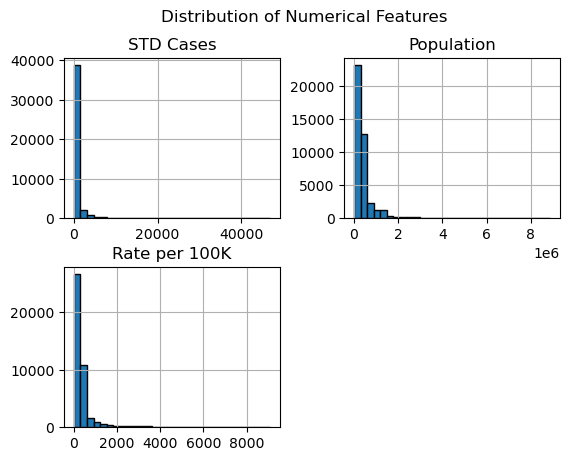

In [12]:
# Plot distribution of numerical features
plt.figure(figsize=(12, 6))
data[['STD Cases', 'Population', 'Rate per 100K']].hist(bins=30, edgecolor='black', layout=(2, 2))
plt.suptitle('Distribution of Numerical Features')
plt.show()

In [13]:
# Encode categorical variables using LabelEncoder
label_encoders = {}

# Columns to encode
columns_to_encode = ['Disease', 'State', 'Gender', 'Age', 'Age Code']

for column in columns_to_encode:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

In [14]:
data.head()

,Disease,Disease Code,State,Year,Gender,Age,Age Code,STD Cases,Population,Rate per 100K
0,0,274.0,0,1996,1,0,0,25.0,468394.0,5.34
1,0,274.0,0,1996,1,1,1,164.0,165920.0,98.84
2,0,274.0,0,1996,1,2,2,193.0,152848.0,126.27
3,0,274.0,0,1996,1,3,3,88.0,152778.0,57.60
4,0,274.0,0,1996,1,4,4,55.0,155850.0,35.29


In [18]:
# Initialize the models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Classifier': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

In [21]:
data.isnull().sum()

Disease          0
Disease Code     0
State            0
Year             0
Gender           0
Age              0
Age Code         0
STD Cases        0
Population       0
Rate per 100K    0
dtype: int64

In [23]:
data.isnull().sum()

Disease          0
Disease Code     0
State            0
Year             0
Gender           0
Age              0
Age Code         0
STD Cases        0
Population       0
Rate per 100K    0
dtype: int64

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42530 entries, 0 to 42629
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Disease        42530 non-null  int32  
 1   Disease Code   42530 non-null  float64
 2   State          42530 non-null  int32  
 3   Year           42530 non-null  int32  
 4   Gender         42530 non-null  int32  
 5   Age            42530 non-null  int32  
 6   Age Code       42530 non-null  int32  
 7   STD Cases      42530 non-null  float64
 8   Population     42530 non-null  float64
 9   Rate per 100K  42530 non-null  float64
dtypes: float64(4), int32(6)
memory usage: 2.6 MB


In [25]:
data.nunique()

Disease              3
Disease Code         3
State               51
Year                19
Gender               3
Age                  8
Age Code             8
STD Cases         4230
Population       12698
Rate per 100K    20044
dtype: int64

In [27]:
# Define feature names and target variable
X = data[['Disease Code', 'State', 'Year', 'Gender', 'Age', 'Age Code', 'Population', 'Rate per 100K']]
y = data['STD Cases']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_train_pred_lr = lr.predict(X_train_scaled)
y_test_pred_lr = lr.predict(X_test_scaled)
print('Logistic Regression Train Accuracy:', accuracy_score(y_train, y_train_pred_lr))
print('Logistic Regression Test Accuracy:', accuracy_score(y_test, y_test_pred_lr))
print(classification_report(y_test, y_test_pred_lr))

MemoryError: Unable to allocate 979. MiB for an array with shape (34024, 3770) and data type float64

In [31]:
print(data.memory_usage(deep=True))

# Convert float64 columns to float32
data = data.astype({col: 'float32' for col in data.select_dtypes(include=['float64']).columns})
data = data.astype({col: 'int32' for col in data.select_dtypes(include=['int64']).columns})

# Check again after conversion
print(data.memory_usage(deep=True))

Index            340240
Disease          170120
Disease Code     340240
State            170120
Year             170120
Gender           170120
Age              170120
Age Code         170120
STD Cases        340240
Population       340240
Rate per 100K    340240
dtype: int64
Index            340240
Disease          170120
Disease Code     170120
State            170120
Year             170120
Gender           170120
Age              170120
Age Code         170120
STD Cases        170120
Population       170120
Rate per 100K    170120
dtype: int64
